--- 1. LOADING MULTIMODAL DATA ---
Features mapped: ['total_orders', 'total_spend', 'avg_order_value', 'total_items_purchased', 'avg_sentiment', 'min_sentiment', 'total_urgent_emails', 'total_emails_sent']

--- 2. TRAINING THE XGBOOST MODEL ---
Model training complete.

--- 3. EVALUATING PERFORMANCE ---
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       817
           1       0.88      0.87      0.88      1814

    accuracy                           0.83      2631
   macro avg       0.80      0.81      0.80      2631
weighted avg       0.83      0.83      0.83      2631

Confusion Matrix:
[True Actives(0)   False Churns(1)] -> [609 208]
[False Actives(0)  True Churns(1)]  -> [ 241 1573]

--- 4. FEATURE IMPORTANCE VISUALIZATION ---


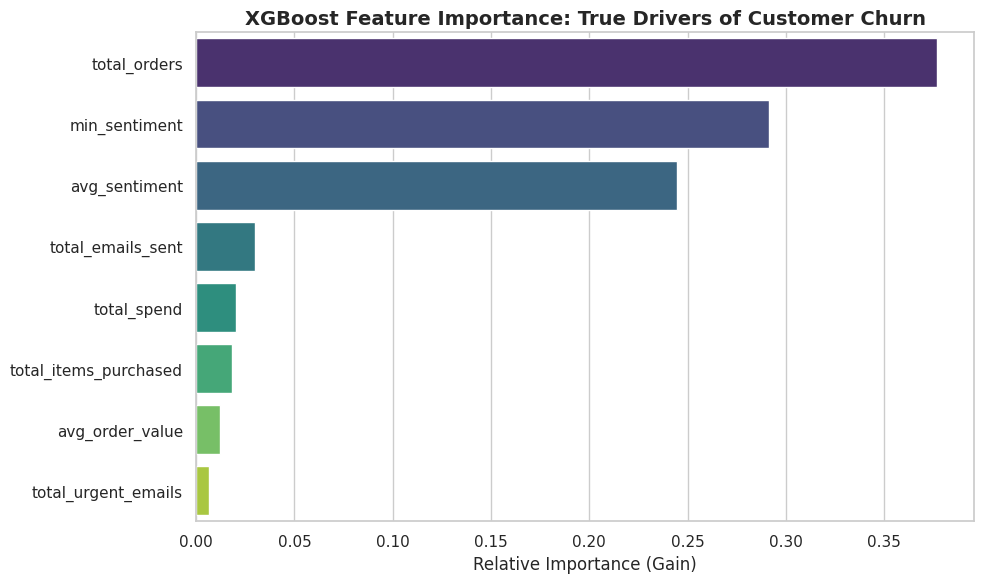

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

PROCESSED_DIR = "../data/processed/"

print("--- 1. LOADING MULTIMODAL DATA ---")
df = pd.read_parquet(os.path.join(PROCESSED_DIR, "master_training_set.parquet"))

# FIX 1: Drop the target variable AND the leaky feature
X = df.drop(columns=['customer_id', 'is_churned', 'days_since_last_order'])
y = df['is_churned']

print(f"Features mapped: {X.columns.tolist()}")

print("\n--- 2. TRAINING THE XGBOOST MODEL ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# FIX 2: Removed use_label_encoder=False to silence the XGBoost warning
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("Model training complete.")

print("\n--- 3. EVALUATING PERFORMANCE ---")
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n[True Actives(0)   False Churns(1)] -> {cm[0]}")
print(f"[False Actives(0)  True Churns(1)]  -> {cm[1]}")

print("\n--- 4. FEATURE IMPORTANCE VISUALIZATION ---")
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# FIX 3: Added hue='Feature' and legend=False to silence the Seaborn palette warning
sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost Feature Importance: True Drivers of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()